In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
llm  = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
def chat_node(state: ChatState):
    
    #take user query from state
    messages = state['messages']

    #send to llm 
    response = llm.invoke(messages)

    #response store state 
    return {'messages' : [response]}


In [5]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

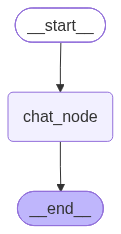

In [6]:
chatbot

In [7]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is **New Delhi**.'